# Reverse Auction Analytics — Vendor Scoring Engine

This notebook builds a custom vendor scoring and classification system for reverse auction bid data.  
It engineers two performance metrics — **Consistency Score** and **Competitiveness Score** — and classifies vendors into performance quadrants.

**Dataset:** 4,176 bids across 10 vendors and 3 auction lots (anonymized)  
**Pipeline stages:** Load → Clean → Consistency Score → Competitiveness Score → Classify → Visualize

---
## 1. Setup & Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

def clean_currency(col_series):
    return col_series.astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

df = pd.read_csv('data/reverse_auction_bids.csv')
df.columns = df.columns.str.strip()

print(f'Rows loaded  : {len(df)}')
print(f'Vendors      : {df["Vendor"].nunique()}')
print(f'Auction Lots : {df["Auction Lot"].nunique()}')

currency_columns = ['Initial Quote for BOC', 'Target Price', 'Pre-Bid Price', 'Bid Price',
                    'Target Spend', 'Current Spend', 'Pre-Bid Spend', 'Bid Spend']
for col in currency_columns:
    if col in df.columns:
        df[col] = clean_currency(df[col])

if '% Delta to Target' in df.columns:
    df['% Delta to Target'] = df['% Delta to Target'].astype(str).str.replace('%', '', regex=False).astype(float) / 100

print('\nData cleaned.')
df.head(3)

---
## 2. Consistency Score

**Logic:** Measures *reliability* — how often a vendor meets or beats the target price.  
**Formula:** `(Bids where delta ≤ 0) / (Total Bids) × 100`

A vendor with 80% Consistency Score meets the target 8 out of 10 times.

In [ ]:
consistency = df.groupby('Vendor').agg(
    Total_Bids=('Auction Lot', 'count'),
    Bids_At_Or_Below_Target=('% Delta to Target', lambda x: (x <= 0).sum()),
    Average_Delta=('% Delta to Target', 'mean'),
    Median_Delta=('% Delta to Target', 'median')
).reset_index()

consistency['Consistency_Score'] = (
    consistency['Bids_At_Or_Below_Target'] / consistency['Total_Bids']
) * 100

print('Consistency scores:')
print(consistency[['Vendor', 'Total_Bids', 'Bids_At_Or_Below_Target', 'Consistency_Score']]
      .sort_values('Consistency_Score', ascending=False).to_string(index=False))

---
## 3. Competitiveness Score

**Logic:** Measures *pricing aggressiveness* — how much a vendor saves when they do win.  
**Formula:** Average `|% delta|` for successful bids only (delta ≤ 0)

Only successful bids are included — vendors that never win score 0.

In [ ]:
def calc_competitiveness(delta_series):
    successful = delta_series[delta_series <= 0]
    if len(successful) == 0:
        return 0
    return abs(successful.mean()) * 100

competitiveness = df.groupby('Vendor').agg(
    Successful_Bids=('% Delta to Target', lambda x: (x <= 0).sum()),
    Failed_Bids=('% Delta to Target', lambda x: (x > 0).sum()),
    Competitiveness_Score=('% Delta to Target', calc_competitiveness),
    Avg_Target_Price=('Target Price', 'mean'),
    Avg_Bid_Price=('Bid Price', 'mean')
).reset_index()

print('Competitiveness scores:')
print(competitiveness[['Vendor', 'Successful_Bids', 'Failed_Bids', 'Competitiveness_Score']]
      .sort_values('Competitiveness_Score', ascending=False).to_string(index=False))

---
## 4. Merge & Classify

Combine both scores and classify vendors into **High / Medium / Low** on each dimension.

In [ ]:
vendor_df = pd.merge(
    consistency[['Vendor', 'Total_Bids', 'Consistency_Score', 'Bids_At_Or_Below_Target', 'Average_Delta']],
    competitiveness[['Vendor', 'Competitiveness_Score', 'Successful_Bids', 'Failed_Bids', 'Avg_Target_Price', 'Avg_Bid_Price']],
    on='Vendor'
)

def classify_consistency(score):
    if score >= 70: return 'High'
    elif score >= 40: return 'Medium'
    return 'Low'

def classify_competitiveness(score):
    if score >= 7: return 'High'
    elif score >= 5: return 'Medium'
    return 'Low'

vendor_df['Consistency_Level']    = vendor_df['Consistency_Score'].apply(classify_consistency)
vendor_df['Competitiveness_Level'] = vendor_df['Competitiveness_Score'].apply(classify_competitiveness)
vendor_df['Combined_Level'] = vendor_df.apply(
    lambda r: 'High' if r['Consistency_Level'] == 'High' and r['Competitiveness_Level'] == 'High'
              else 'Low' if r['Consistency_Level'] == 'Low' or r['Competitiveness_Level'] == 'Low'
              else 'Medium', axis=1
)

vendor_df = vendor_df.sort_values(['Consistency_Score', 'Competitiveness_Score'], ascending=False)
print(vendor_df[['Vendor','Consistency_Score','Competitiveness_Score','Consistency_Level','Competitiveness_Level']].to_string(index=False))

---
## 5. Quadrant Scatter Plot

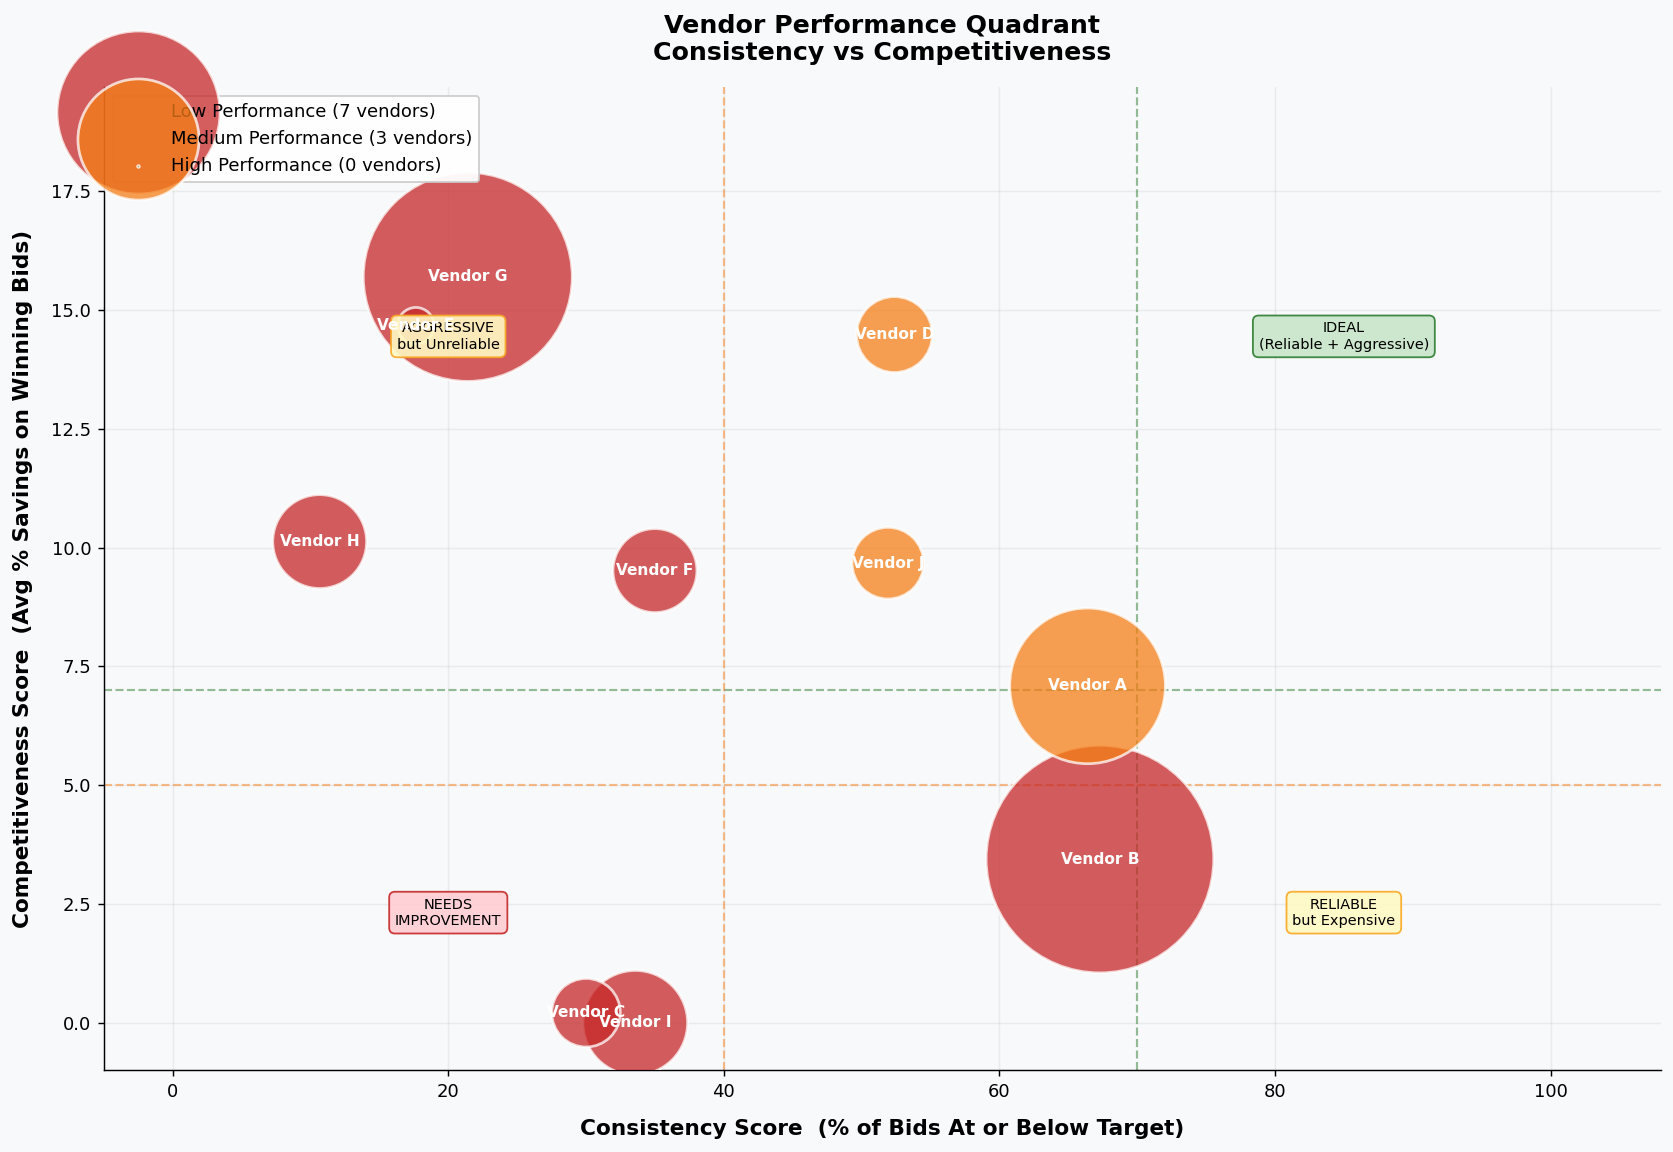

In [11]:
color_map = {'High': 'darkgreen', 'Medium': 'orange', 'Low': 'red'}

fig, ax = plt.subplots(figsize=(14, 10))

for level in ['Low', 'Medium', 'High']:
    sub = vendor_df[vendor_df['Combined_Level'] == level]
    ax.scatter(sub['Consistency_Score'], sub['Competitiveness_Score'],
               s=sub['Total_Bids'] * 10, alpha=0.6, c=color_map[level],
               label=f'{level} Performance', edgecolors='black', linewidth=0.5)

for _, row in vendor_df.iterrows():
    ax.annotate(row['Vendor'],
                xy=(row['Consistency_Score'], row['Competitiveness_Score']),
                fontsize=8, ha='center', va='center', fontweight='bold',
                color='white')

ax.axhline(y=7, color='darkgreen', linestyle='--', alpha=0.6, linewidth=1.5)
ax.axhline(y=5, color='orange',    linestyle='--', alpha=0.6, linewidth=1.5)
ax.axvline(x=70, color='darkgreen', linestyle='--', alpha=0.6, linewidth=1.5)
ax.axvline(x=40, color='orange',   linestyle='--', alpha=0.6, linewidth=1.5)

ax.set_xlabel('Consistency Score (% Bids At or Below Target)', fontsize=12, fontweight='bold')
ax.set_ylabel('Competitiveness Score (Avg % Savings on Wins)', fontsize=12, fontweight='bold')
ax.set_title('Vendor Classification: Consistency vs Competitiveness\n(Bubble size = Number of Bids)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/vendor_quadrant.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved.')

---
## 6. Top 10 Combined Score Bar Chart

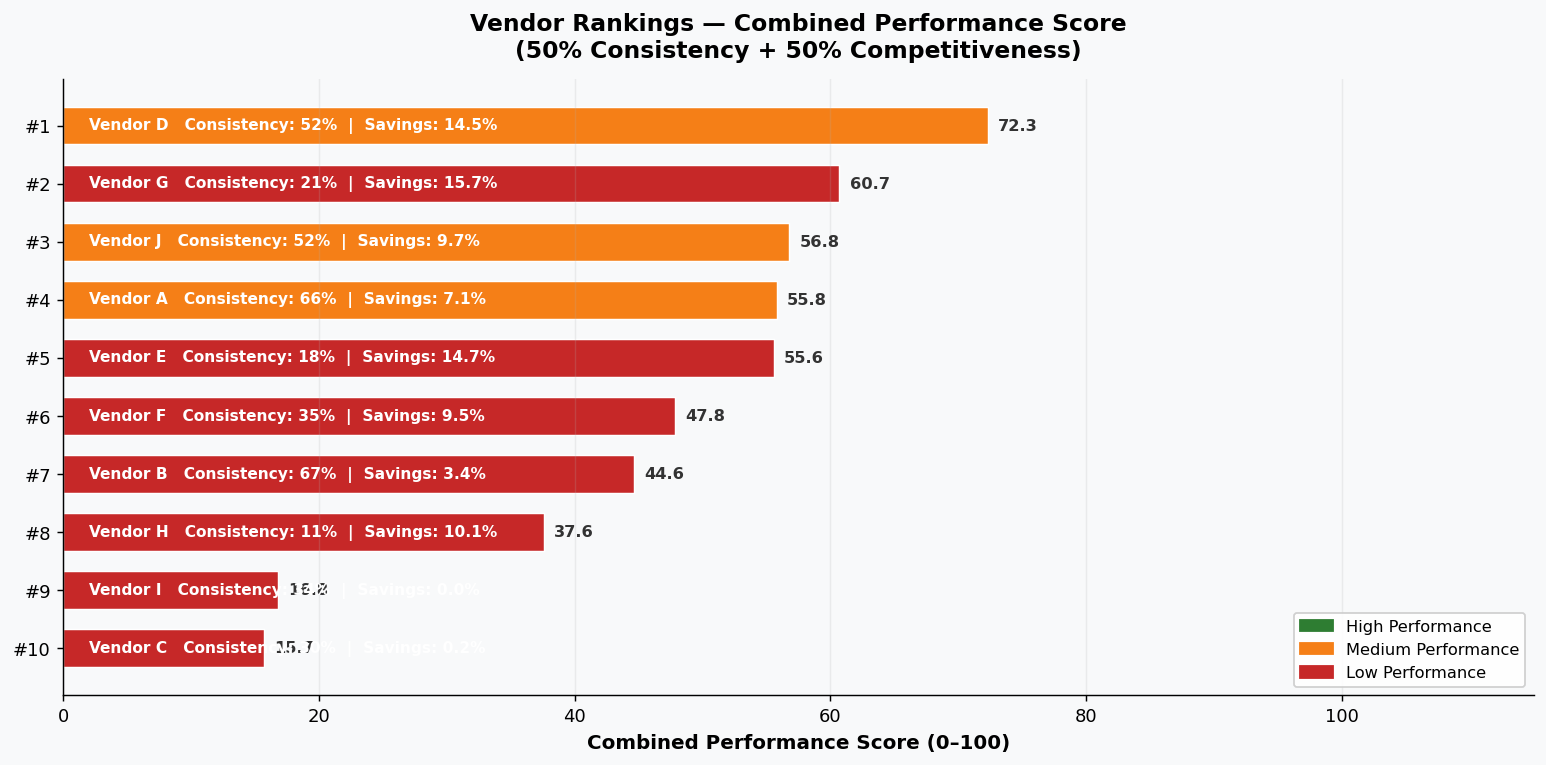

In [13]:
max_comp = vendor_df['Competitiveness_Score'].max()
vendor_df['Competitiveness_Normalized'] = vendor_df['Competitiveness_Score'] / max_comp * 100 if max_comp > 0 else 0
vendor_df['Combined_Score'] = (vendor_df['Consistency_Score'] * 0.5 +
                                vendor_df['Competitiveness_Normalized'] * 0.5)

top10 = vendor_df.nlargest(10, 'Combined_Score')
colors = [color_map[l] for l in top10['Combined_Level']]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(range(len(top10)), top10['Combined_Score'], color=colors, edgecolor='black', linewidth=0.8)

for i, (_, row) in enumerate(top10.iterrows()):
    ax.text(row['Combined_Score'] + 0.5, i, f"{row['Combined_Score']:.1f}", va='center', fontweight='bold')
    ax.text(3, i, f"{row['Vendor']}  (Consistency: {row['Consistency_Score']:.0f}% | Savings: {row['Competitiveness_Score']:.1f}%)",
            va='center', fontsize=8, color='white', fontweight='bold')

ax.set_xlabel('Combined Performance Score', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Vendors — Combined Performance Score\n(50% Consistency + 50% Competitiveness)', fontsize=13, fontweight='bold')
ax.set_yticks(range(len(top10)))
ax.set_yticklabels([f'#{i+1}' for i in range(len(top10))])
ax.invert_yaxis()
ax.set_xlim(0, 110)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('data/top_vendors.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved.')

---
## 7. Summary

This pipeline classified 10 vendors across two custom-engineered metrics:

| Metric | What it measures | Formula |
|---|---|---|
| Consistency Score | Bid reliability — how often vendor meets target | % of bids with delta ≤ 0 |
| Competitiveness Score | Pricing aggressiveness — how much they save when they win | Avg |delta| for successful bids |

**Quadrant logic:**
- High / High → Ideal vendor: reliable AND aggressive
- High / Low → Safe but expensive: meets target but minimal savings
- Low / High → Risky: great savings when they win, but unreliable
- Low / Low → Underperforming: neither reliable nor price-competitive

In a production pipeline, this notebook would ingest new auction data automatically and output an updated vendor scorecard for sourcing decisions.